In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error,mean_squared_error
import matplotlib.pyplot as plt
import warnings,gc,os
warnings.filterwarnings('ignore')

In [ ]:
sales=pd.read_feather("/kaggle/input/datasets/#####/xg-scaled/sales_features.feather")
sales

,item_id,store_id,dept_id,cat_id,state_id,sales,date,sell_price,snap_CA,lag_7,...,year,week_of_yr,is_weekend,quarter,has_event,event_type_enc,price_change,price_rel_mean,price_direction,event_name_enc
0,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,3,2011-01-29,2.00,0,NaN,...,2011,4,1,1,0,0,NaN,0.923653,0,0
1,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,0,2011-01-30,2.00,0,NaN,...,2011,4,1,1,0,0,0.0,0.923653,0,0
2,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,0,2011-01-31,2.00,0,NaN,...,2011,5,0,1,0,0,0.0,0.923653,0,0
3,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,1,2011-02-01,2.00,1,NaN,...,2011,5,0,1,0,0,0.0,0.923653,0,0
4,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,4,2011-02-02,2.00,1,NaN,...,2011,5,0,1,0,0,0.0,0.923653,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,HOUSEHOLD_2_516,WI_3,HOUSEHOLD_2,HOUSEHOLD,WI,0,2016-05-18,5.94,0,0.0,...,2016,20,0,2,0,0,0.0,1.000601,0,0
59181086,HOUSEHOLD_2_516,WI_3,HOUSEHOLD_2,HOUSEHOLD,WI,0,2016-05-19,5.94,0,0.0,...,2016,20,0,2,0,0,0.0,1.000601,0,0
59181087,HOUSEHOLD_2_516,WI_3,HOUSEHOLD_2,HOUSEHOLD,WI,0,2016-05-20,5.94,0,0.0,...,2016,20,0,2,0,0,0.0,1.000601,0,0
59181088,HOUSEHOLD_2_516,WI_3,HOUSEHOLD_2,HOUSEHOLD,WI,0,2016-05-21,5.94,0,1.0,...,2016,20,1,2,0,0,0.0,1.000601,0,0


In [4]:
import os,gc

In [5]:
sales=sales.dropna(subset=['lag_28']).reset_index(drop=True)
gc.collect()


0

In [7]:
feature_cols = [
    # lag features
    'lag_7', 'lag_14', 'lag_28',
    # rolling features
    'roll_mean_7', 'roll_mean_28', 'roll_std_7', 'roll_std_28',
    # calendar
    'day_of_week', 'month', 'year', 'week_of_yr', 'is_weekend', 'quarter',
    # external
    'snap_CA', 'has_event', 'event_type_enc', 'event_name_enc',
    # price
    'sell_price', 'price_change', 'price_rel_mean', 'price_direction'
]
target_col='sales'

In [8]:
sales['date']=pd.to_datetime(sales['date'])
cutoff_date=sales['date'].max() -pd.Timedelta(days=28)

In [9]:
train=sales[sales['date']<=cutoff_date]
test=sales[sales['date']>cutoff_date]
X_train=train[feature_cols]
y_train=train[target_col].astype('float32')

In [10]:
del(sales)
gc.collect()

0

In [11]:
X_test=test[feature_cols]
y_test=test[target_col].astype('float32')

In [12]:
print(f"Train : {train['date'].min().date()} → {train['date'].max().date()} ({len(train):,} rows)")
print(f"Test  : {test['date'].min().date()}  → {test['date'].max().date()} ({len(test):,} rows)")
print(f"X_train shape : {X_train.shape}")
print(f"X_test shape  : {X_test.shape}")

Train : 2011-02-26 → 2016-04-24 (57,473,650 rows)
Test  : 2016-04-25  → 2016-05-22 (853,720 rows)
X_train shape : (57473650, 21)
X_test shape  : (853720, 21)


In [13]:
val_cutoff_date=train['date'].max() -pd.Timedelta(days=28)
train_cutoff=train[train['date']<=val_cutoff_date]
val=train[train['date']>val_cutoff_date]

In [15]:
xgb_params = {
    'objective'        : 'reg:squarederror',
    'n_estimators'     : 500,
    'learning_rate'    : 0.05,
    'max_depth'        : 6,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'min_child_weight' : 10,
    'tree_method'      : 'hist',   # fast histogram method
    'random_state'     : 42,
    'n_jobs'           : -1        # use all CPU cores
}

model_xgb = xgb.XGBRegressor(
    **xgb_params,
    early_stopping_rounds=50
)

model_xgb.fit(
    train_cutoff[feature_cols], train_cutoff[target_col].astype('float32'),
    eval_set=[(val[feature_cols], val[target_col].astype('float32'))],
    verbose=50
)
print(f"Best iteration : {model_xgb.best_iteration}")
print(f"Best RMSE      : {model_xgb.best_score:.5f}")

print("Training completed")

[0]	validation_0-rmse:3.48095
[50]	validation_0-rmse:2.01087
[100]	validation_0-rmse:1.99321
[150]	validation_0-rmse:1.98830
[200]	validation_0-rmse:1.98544
[250]	validation_0-rmse:1.98293
[300]	validation_0-rmse:1.98047
[350]	validation_0-rmse:1.97888
[400]	validation_0-rmse:1.97809
[450]	validation_0-rmse:1.97726
[499]	validation_0-rmse:1.97687
Best iteration : 487
Best RMSE      : 1.97661
Training completed


In [ ]:
y_pred = model_xgb.predict(X_test)

# Clip negative predictions — sales can't be negative
y_pred = np.clip(y_pred, 0, None)

# Metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
zero_rate = (y_test == 0).mean()

# MASE — Mean Absolute Scaled Error 
naive_mae = mean_absolute_error(y_test[1:], y_test[:-1])
mase = mae / naive_mae if naive_mae > 0 else float('inf')

print("=" * 40)
print("XGBoost — 28-day forecast evaluation")
print("=" * 40)
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MASE  : {mase:.4f}  (< 1.0 = beats naive forecast)")
print(f"Zero-sale rate in test: {zero_rate:.1%}")
print("=" * 40)

XGBoost — 28-day forecast evaluation
MAE   : 1.0029
RMSE  : 2.0020
MASE  : 0.8087  (< 1.0 = beats naive forecast)
Zero-sale rate in test: 54.4%


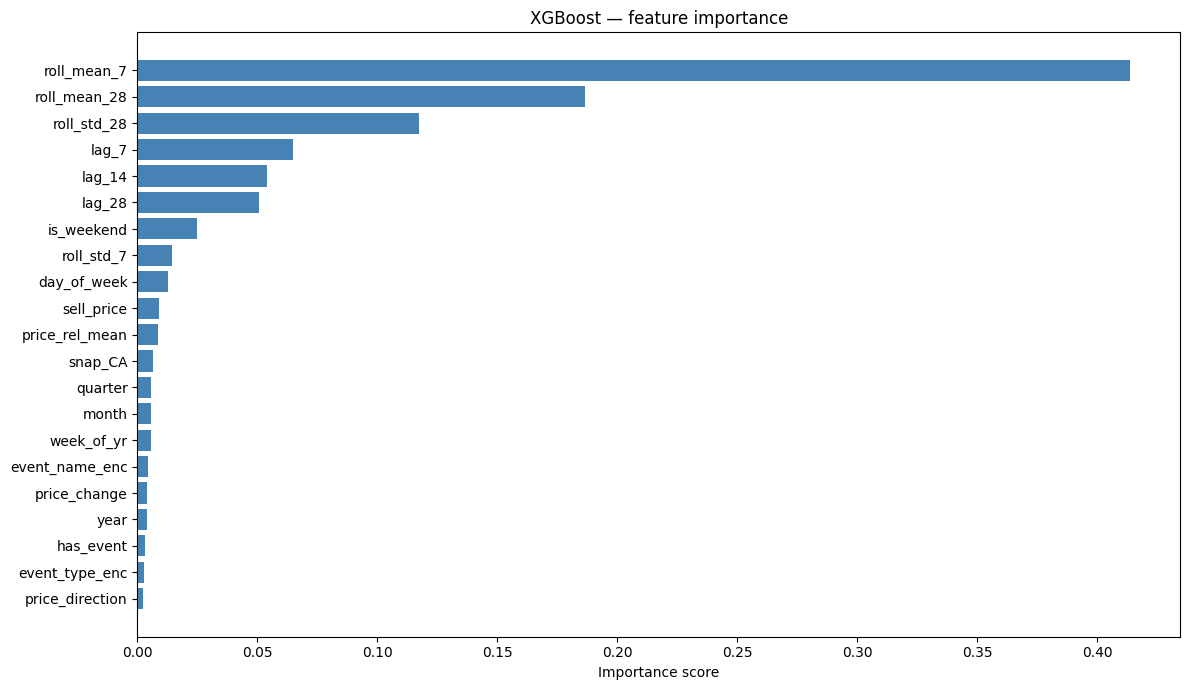

        feature  importance
    roll_mean_7    0.413786
   roll_mean_28    0.186591
    roll_std_28    0.117164
          lag_7    0.064749
         lag_14    0.053793
         lag_28    0.050600
     is_weekend    0.024767
     roll_std_7    0.014586
    day_of_week    0.012573
     sell_price    0.008843
 price_rel_mean    0.008485
        snap_CA    0.006446
        quarter    0.005752
          month    0.005709
     week_of_yr    0.005566
 event_name_enc    0.004338
   price_change    0.004040
           year    0.003832
      has_event    0.003122
 event_type_enc    0.002920
price_direction    0.002338


In [17]:
importance = pd.DataFrame({
    'feature'    : feature_cols,
    'importance' : model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 7))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.title('XGBoost — feature importance')
plt.xlabel('Importance score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.to_string(index=False))

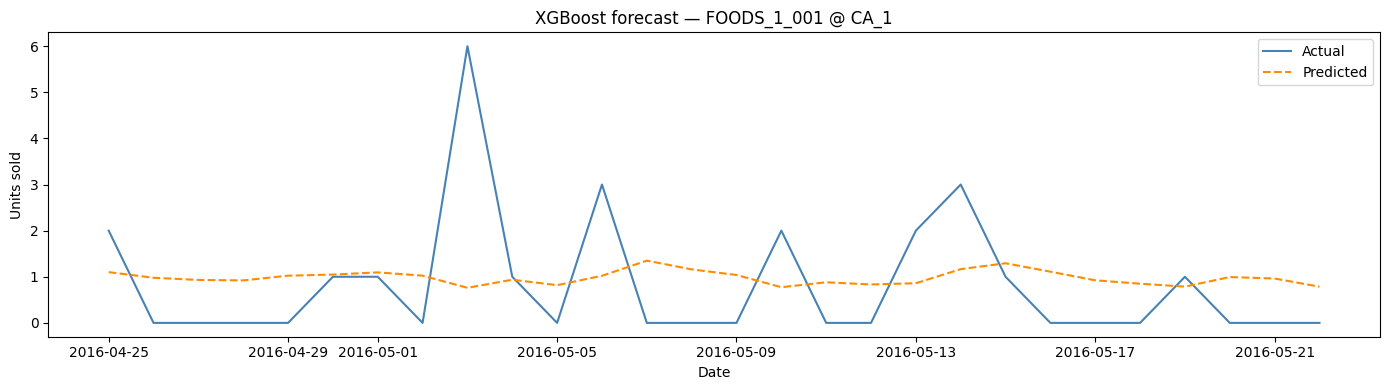

In [18]:
# Sample one item-store for visual inspection
sample_item  = 'FOODS_1_001'
sample_store = 'CA_1'

sample = test[
    (test['item_id'] == sample_item) &
    (test['store_id'] == sample_store)
].copy()

sample_idx   = sample.index
sample_pred  = y_pred[test.index.get_indexer(sample_idx)]

plt.figure(figsize=(14, 4))
plt.plot(sample['date'], sample['sales'].values, label='Actual',    color='steelblue')
plt.plot(sample['date'], sample_pred,             label='Predicted', color='darkorange', linestyle='--')
plt.title(f'XGBoost forecast — {sample_item} @ {sample_store}')
plt.xlabel('Date')
plt.ylabel('Units sold')
plt.legend()
plt.tight_layout()
plt.show()

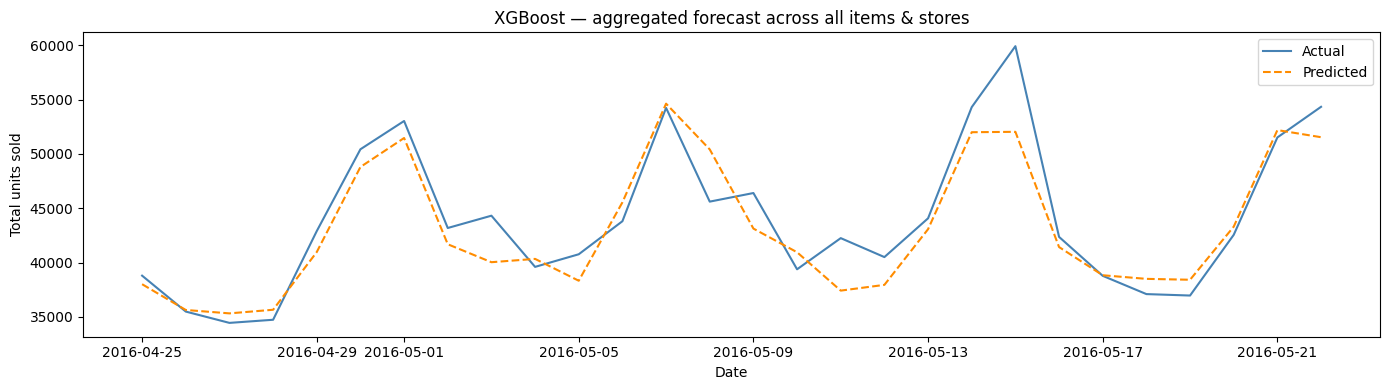

In [ ]:
# Aggregated forecast (more meaningful than single item)
agg_actual = test.groupby('date')['sales'].sum()
agg_pred   = test.copy()
agg_pred['xgb_pred'] = y_pred
agg_pred   = agg_pred.groupby('date')['xgb_pred'].sum()

plt.figure(figsize=(14,4))
plt.plot(agg_actual.index, agg_actual.values, label='Actual',    color='steelblue')
plt.plot(agg_pred.index,   agg_pred.values,   label='Predicted', color='darkorange', linestyle='--')
plt.title('XGBoost — aggregated forecast across all items & stores')
plt.xlabel('Date'); plt.ylabel('Total units sold')
plt.legend(); plt.tight_layout(); plt.show()

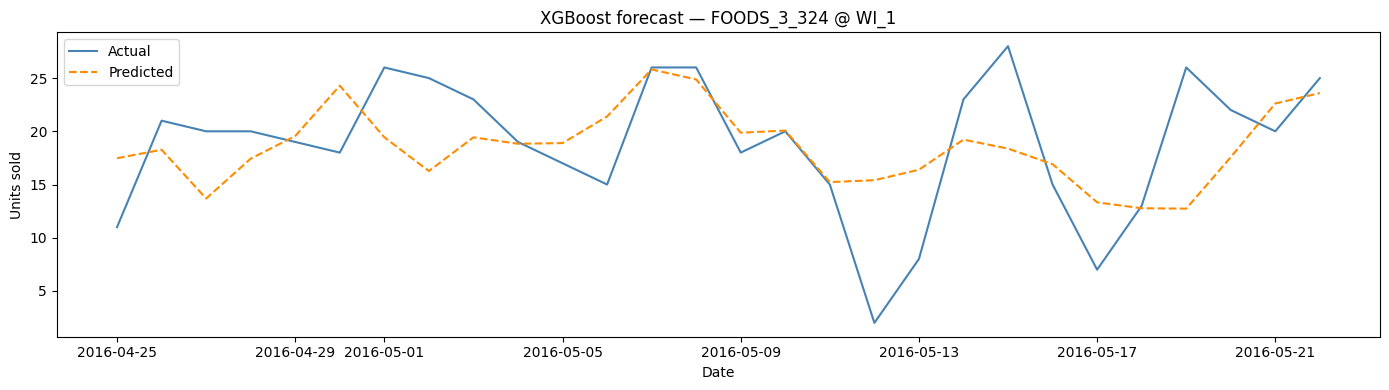

In [21]:
# Sample one item-store for visual inspection
sample_item  = 'FOODS_3_324'
sample_store = 'WI_1'

sample = test[
    (test['item_id'] == sample_item) &
    (test['store_id'] == sample_store)
].copy()

sample_idx   = sample.index
sample_pred  = y_pred[test.index.get_indexer(sample_idx)]

plt.figure(figsize=(14, 4))
plt.plot(sample['date'], sample['sales'].values, label='Actual',    color='steelblue')
plt.plot(sample['date'], sample_pred,             label='Predicted', color='darkorange', linestyle='--')
plt.title(f'XGBoost forecast — {sample_item} @ {sample_store}')
plt.xlabel('Date')
plt.ylabel('Units sold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Aggregate to daily level for top 50 items @ CA_1 FOODS_1 and saving them

test_results = test[['item_id','store_id','date','sales']].copy()
test_results['xgb_pred'] = y_pred

# Filter to top 50 items @ CA_1 FOODS_1
top_items = [
    'FOODS_1_004', 'FOODS_1_012', 'FOODS_1_018', 'FOODS_1_019', 'FOODS_1_021', 
    'FOODS_1_032', 'FOODS_1_036', 'FOODS_1_040', 'FOODS_1_042', 'FOODS_1_043', 
    'FOODS_1_044', 'FOODS_1_045', 'FOODS_1_046', 'FOODS_1_054', 'FOODS_1_055', 
    'FOODS_1_058', 'FOODS_1_067', 'FOODS_1_082', 'FOODS_1_085', 'FOODS_1_086', 
    'FOODS_1_087', 'FOODS_1_099', 'FOODS_1_104', 'FOODS_1_110', 'FOODS_1_112', 
    'FOODS_1_113', 'FOODS_1_120', 'FOODS_1_130', 'FOODS_1_137', 'FOODS_1_139', 
    'FOODS_1_153', 'FOODS_1_154', 'FOODS_1_161', 'FOODS_1_162', 'FOODS_1_163', 
    'FOODS_1_166', 'FOODS_1_170', 'FOODS_1_172', 'FOODS_1_173', 'FOODS_1_181', 
    'FOODS_1_183', 'FOODS_1_184', 'FOODS_1_194', 'FOODS_1_200', 'FOODS_1_201', 
    'FOODS_1_204', 'FOODS_1_206', 'FOODS_1_217', 'FOODS_1_218', 'FOODS_1_219'
]
xgb_item_level = test_results[
    (test_results['store_id'] == 'CA_1') &
    (test_results['item_id'].isin(top_items))
].copy()

# 2. Keep only the columns we need for the DM test
xgb_item_level = xgb_item_level[['date', 'item_id', 'sales', 'xgb_pred']].copy()
xgb_item_level.rename(columns={'sales': 'actual'}, inplace=True)

# 3. Sort chronologically and alphabetically to match TFT perfectly
xgb_item_level.sort_values(['item_id', 'date'], inplace=True)
xgb_item_level.reset_index(drop=True, inplace=True)

xgb_item_level.to_feather('xgb_aggr.feather')
xgb_item_level.to_csv('xgb_aggr.csv', index=False)
print(f"XGBoost saved Shape: {xgb_item_level.shape}")
print(xgb_item_level.head())